In [1]:
!apt-get install git

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.15).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [2]:
!git clone https://github.com/sripragnabitra/BankChequeForgeryDetection.git

Cloning into 'BankChequeForgeryDetection'...


In [3]:
%cd BankChequeForgeryDetection


/content/BankChequeForgeryDetection


In [4]:
!git config --global user.email "sripragnabitra@gmail.com"
!git config --global user.name "sripragnabitra"

In [5]:
!git add .
!git commit -m "Add my Colab notebook"
!git push

On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec refs/heads/main does not match any
error: failed to push some refs to 'https://github.com/sripragnabitra/BankChequeForgeryDetection.git'


In [ ]:
# Upload Dataset
from google.colab import files
uploaded = files.upload()

Saving Images.rar to Images.rar


In [ ]:
!pip install rarfile
import rarfile, os

# Define the path to your uploaded file
rar_path = "Images.rar"

# Extract contents
with rarfile.RarFile(rar_path) as rf:
    rf.extractall("/content/WriterIdentification")

DATASET_PATH = "/content/WriterIdentification/images"
print("Dataset extracted to:", DATASET_PATH)
print("Total files:", sum(len(files) for _, _, files in os.walk(DATASET_PATH)))

Dataset extracted to: /content/WriterIdentification/images
Total files: 0


In [ ]:
import os, random, cv2, numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_recall_curve, f1_score, classification_report
from sklearn.utils import shuffle
from itertools import combinations
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input, models, regularizers, applications
from tensorflow.keras.optimizers import Adam

In [ ]:
# Dataset Analysis
DATASET_PATH = "/content/WriterIdentification"
IMG_H, IMG_W = 200, 100

random.seed(42); np.random.seed(42)

def build_images_by_writer(root):
    valid_ext = ('.png','.jpg','.jpeg','.bmp','.tif','.tiff')
    images_by_writer = defaultdict(list)
    files = sorted([f for f in os.listdir(root) if f.lower().endswith(valid_ext)])
    if not files:
        raise RuntimeError("No images found in DATASET_PATH")

    for fn in files:
        writer = fn.split("_")[0]
        writer = writer.split("b")[1]
        images_by_writer[writer].append(os.path.join(root, fn))

    return images_by_writer

images_by_writer = build_images_by_writer(DATASET_PATH)

writer_ids = list(images_by_writer.keys())

counts = [len(images_by_writer[w]) for w in writer_ids]
total_images = sum(counts)

print(f"Number of writers detected: {len(writer_ids)}")
print(f"Total word images: {total_images}\n")
print("Writer IDs:", writer_ids, "\n")

Number of writers detected: 50
Total word images: 500

Writer IDs: ['10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '1', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '3', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '4', '50', '5', '6', '7', '8', '9'] 



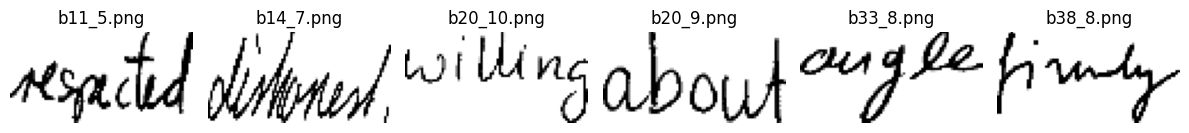

In [ ]:
def show_examples(images_by_writer, n=6):
    all_paths = [p for paths in images_by_writer.values() for p in paths]
    sample = random.sample(all_paths, min(n, len(all_paths)))

    plt.figure(figsize=(12,3))
    for i, path in enumerate(sample, 1):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (80, 40))
        plt.subplot(1, len(sample), i)
        plt.imshow(img, cmap='gray')
        plt.title(os.path.basename(path))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_examples(images_by_writer, 6)


In [ ]:
# Preview potential pair counts
def potential_pair_counts(writer_set):
    wrs = list(writer_set)
    ns = [len(images_by_writer[w]) for w in wrs]
    S = int(sum(n*(n-1)//2 for n in ns))
    D = 0
    for i in range(len(ns)):
        for j in range(i+1, len(ns)):
            D += ns[i]*ns[j]
    return S, D

S_all, D_all = potential_pair_counts(writer_ids)
print(f"Potential unordered pairs (whole dataset):\nSame-writer: {S_all}, Diff-writer: {D_all}")

Potential unordered pairs (whole dataset):
Same-writer: 2250, Diff-writer: 122500


In [ ]:
# Preprocess
def preprocess_img(path, mode="gray"):
    if mode == "gray":
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_W, IMG_H))
        img = img.astype("float32") / 255.0
        return np.expand_dims(img, -1)

    elif mode == "rgb":
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_W, IMG_H))
        img = img.astype("float32") / 255.0
        return img

In [ ]:
# Leave-10-writer-out
def leave_k_out(writers_list, k=10):
    writers_list = writers_list.copy()
    random.shuffle(writers_list)
    test = set(writers_list[:k])
    train = set(writers_list[k:])
    return train, test

In [ ]:
random.seed(42); np.random.seed(42)

def positive_pairs_paths(writer_set, img_dict):
    pairs = []
    for w in writer_set:
        paths = img_dict[w]
        for i, j in combinations(range(len(paths)), 2):
            pairs.append((paths[i], paths[j]))
    return pairs

def negative_pairs_paths(writer_set, img_dict):
    valid_wrs = [w for w in writer_set if len(img_dict.get(w, [])) > 0]
    if len(valid_wrs) < 2:
        return []
    rng = np.random.RandomState(42)
    pairs = []
    W = len(valid_wrs)
    for _ in range(S_all):
        i, j = rng.choice(W, size=2, replace=False)
        w_a, w_b = valid_wrs[i], valid_wrs[j]
        pa = rng.choice(img_dict[w_a])
        pb = rng.choice(img_dict[w_b])
        pairs.append((pa, pb))
    return pairs

def sample_n(pool, n):
    if len(pool) >= n:
        idx = np.random.choice(len(pool), n, replace=False)
    else:
        idx = np.random.choice(len(pool), n, replace=True)
    return [pool[i] for i in idx]

def build_arrays(pairs, mode="gray"):
    if len(pairs) == 0:
        shape = (IMG_H, IMG_W, 1) if mode == "gray" else (IMG_H, IMG_W, 3)
        return np.zeros((0,) + shape, dtype=np.float32), np.zeros((0,) + shape, dtype=np.float32)
    A = [preprocess_img(p, mode=mode) for p, q in pairs]
    B = [preprocess_img(q, mode=mode) for p, q in pairs]
    return np.stack(A).astype("float32"), np.stack(B).astype("float32")

train_w, test_w = leave_k_out(writer_ids, k=10)
train_w = list(train_w); test_w = list(test_w)

In [ ]:
pos_train_pool = positive_pairs_paths(train_w, images_by_writer)
pos_test_pool  = positive_pairs_paths(test_w,  images_by_writer)
neg_train_pool = negative_pairs_paths(train_w, images_by_writer)
neg_test_pool  = negative_pairs_paths(test_w,  images_by_writer)

train_neg_sampled = sample_n(neg_train_pool, len(pos_train_pool))
test_neg_sampled  = sample_n(neg_test_pool,  len(pos_test_pool))

A_tr_pos_g, B_tr_pos_g = build_arrays(pos_train_pool, mode="gray")
A_tr_neg_g, B_tr_neg_g = build_arrays(train_neg_sampled, mode="gray")
A_tr_g = np.vstack([A_tr_pos_g, A_tr_neg_g])
B_tr_g = np.vstack([B_tr_pos_g, B_tr_neg_g])
y_tr = np.hstack([np.ones(len(A_tr_pos_g), dtype=np.int32), np.zeros(len(A_tr_neg_g), dtype=np.int32)])

A_te_pos_g, B_te_pos_g = build_arrays(pos_test_pool, mode="gray")
A_te_neg_g, B_te_neg_g = build_arrays(test_neg_sampled, mode="gray")
A_te_g = np.vstack([A_te_pos_g, A_te_neg_g])
B_te_g = np.vstack([B_te_pos_g, B_te_neg_g])
y_te = np.hstack([np.ones(len(A_te_pos_g), dtype=np.int32), np.zeros(len(A_te_neg_g), dtype=np.int32)])

A_tr_pos_rgb, B_tr_pos_rgb = build_arrays(pos_train_pool, mode="rgb")
A_tr_neg_rgb, B_tr_neg_rgb = build_arrays(train_neg_sampled, mode="rgb")
A_tr_rgb = np.vstack([A_tr_pos_rgb, A_tr_neg_rgb])
B_tr_rgb = np.vstack([B_tr_pos_rgb, B_tr_neg_rgb])

A_te_pos_rgb, B_te_pos_rgb = build_arrays(pos_test_pool, mode="rgb")
A_te_neg_rgb, B_te_neg_rgb = build_arrays(test_neg_sampled, mode="rgb")
A_te_rgb = np.vstack([A_te_pos_rgb, A_te_neg_rgb])
B_te_rgb = np.vstack([B_te_pos_rgb, B_te_neg_rgb])

if len(y_tr) > 0:
    perm = np.random.permutation(len(y_tr))
    A_tr_g, B_tr_g, y_tr = A_tr_g[perm], B_tr_g[perm], y_tr[perm]
    A_tr_rgb, B_tr_rgb = A_tr_rgb[perm], B_tr_rgb[perm]

if len(y_te) > 0:
    perm_te = np.random.permutation(len(y_te))
    A_te_g, B_te_g, y_te = A_te_g[perm_te], B_te_g[perm_te], y_te[perm_te]
    A_te_rgb, B_te_rgb = A_te_rgb[perm_te], B_te_rgb[perm_te]


print("Shapes (grayscale):", A_tr_g.shape, B_tr_g.shape, A_te_g.shape, B_te_g.shape)
print("Shapes (rgb)      :", A_tr_rgb.shape, B_tr_rgb.shape, A_te_rgb.shape, B_te_rgb.shape)
print("Labels shapes     :", y_tr.shape, y_te.shape)

print("Train pairs:", len(y_tr), "  Test pairs:", len(y_te))

Shapes (grayscale): (3600, 200, 100, 1) (3600, 200, 100, 1) (900, 200, 100, 1) (900, 200, 100, 1)
Shapes (rgb)      : (3600, 200, 100, 3) (3600, 200, 100, 3) (900, 200, 100, 3) (900, 200, 100, 3)
Labels shapes     : (3600,) (900,)
Train pairs: 3600   Test pairs: 900


In [ ]:
def build_siamese_baseCNN(input_shape=(128,128,3), embed_dim=256, lr=1e-4):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(embed_dim, activation='relu')(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)
    embedder = models.Model(inp, x, name='base_cnn_embedder')

    # Siamese
    a = layers.Input(shape=input_shape)
    b = layers.Input(shape=input_shape)
    ea = embedder(a)
    eb = embedder(b)
    diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]))([ea, eb])
    out = layers.Dense(1, activation='sigmoid')(diff)

    model = models.Model([a, b], out, name='siamese_basecnn')
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model, embedder

In [ ]:
def build_siamese_pretrained(input_shape=(128,128,3), embed_dim=256, lr=1e-4, freeze_backbone=True):
    base = applications.EfficientNetB0(include_top=False, input_shape=input_shape, weights='imagenet', pooling='avg')
    if freeze_backbone:
        for layer in base.layers:
            layer.trainable = False

    inp = layers.Input(shape=input_shape)
    x = layers.RandomFlip("horizontal")(inp)
    x = layers.RandomRotation(0.06)(x)
    x = base(x, training=False)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(embed_dim)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)
    embedder = models.Model(inp, x, name='efn_embedder')

    # Siamese
    a = layers.Input(shape=input_shape)
    b = layers.Input(shape=input_shape)
    ea = embedder(a)
    eb = embedder(b)
    diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]))([ea, eb])
    out = layers.Dense(1, activation='sigmoid')(diff)

    model = models.Model([a, b], out, name='siamese_efficientnet')
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model, embedder


In [ ]:
def se_block(x, ratio=8):
    filters = int(x.shape[-1])
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([x, se])

def cbam_block(x, ratio=8, kernel_size=7):
    filters = int(x.shape[-1])
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)
    mlp = layers.Dense(filters // ratio, activation='relu')
    ch_avg = mlp(avg_pool); ch_avg = layers.Dense(filters)(ch_avg)
    ch_max = mlp(max_pool); ch_max = layers.Dense(filters)(ch_max)
    ch = layers.Add()([ch_avg, ch_max])
    ch = layers.Activation('sigmoid')(ch)
    ch = layers.Reshape((1, 1, filters))(ch)
    x_out = layers.Multiply()([x, ch])
    avg_pool_sp = tf.reduce_mean(x_out, axis=3, keepdims=True)
    max_pool_sp = tf.reduce_max(x_out, axis=3, keepdims=True)
    concat = layers.Concatenate(axis=3)([avg_pool_sp, max_pool_sp])
    sp = layers.Conv2D(1, kernel_size, padding='same', activation='sigmoid')(concat)
    return layers.Multiply()([x_out, sp])

def build_siamese_with_attention(input_shape=(128,128,3), embed_dim=256, attention='se', lr=1e-4):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.MaxPool2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPool2D(2)(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPool2D(2)(x)

    if attention == 'se':
        x = se_block(x, ratio=8)
    elif attention == 'cbam':
        x = cbam_block(x, ratio=8)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(embed_dim)(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)
    embedder = models.Model(inp, x, name=f'att_{attention}_embedder')

    # Siamese
    a = layers.Input(shape=input_shape)
    b = layers.Input(shape=input_shape)
    ea = embedder(a)
    eb = embedder(b)
    diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]))([ea, eb])
    out = layers.Dense(1, activation='sigmoid')(diff)

    model = models.Model([a, b], out, name=f'siamese_{attention}')
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model, embedder


In [ ]:
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding='valid')

    def call(self, x):
        x = self.proj(x)
        B = tf.shape(x)[0]; H = tf.shape(x)[1]; W = tf.shape(x)[2]; D = tf.shape(x)[3]
        return tf.reshape(x, (B, -1, D))

def vit_encoder(image_size=(128,128,3), patch_size=16, embed_dim=256, depth=4, num_heads=8, mlp_dim=512, dropout=0.1):
    H, W, _ = image_size
    inp = layers.Input(shape=image_size)
    patches = PatchEmbedding(patch_size, embed_dim)(inp)
    N = (H // patch_size) * (W // patch_size)
    pos_emb = tf.Variable(tf.random.truncated_normal([1, N, embed_dim], stddev=0.02), trainable=True)
    x = patches + pos_emb

    for _ in range(depth):
        x1 = layers.LayerNormalization()(x)
        attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim//num_heads)(x1, x1)
        x = layers.Add()([x, attn])
        x2 = layers.LayerNormalization()(x)
        mlp = layers.Dense(mlp_dim, activation='gelu')(x2)
        mlp = layers.Dense(embed_dim)(mlp)
        x = layers.Add()([x, mlp])

    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    model = models.Model(inp, x, name='vit_encoder')
    return model

def build_siamese_vit(image_size=(128,128,3), patch_size=16, embed_dim=256, depth=4, num_heads=8, mlp_dim=512, lr=1e-4):
    vit = vit_encoder(image_size=image_size, patch_size=patch_size, embed_dim=embed_dim,
                      depth=depth, num_heads=num_heads, mlp_dim=mlp_dim)
    inp = layers.Input(shape=image_size)
    x = layers.RandomFlip("horizontal")(inp)
    x = layers.RandomRotation(0.06)(x)
    x = vit(x)
    x = layers.Dense(embed_dim)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)
    embedder = models.Model(inp, x, name='vit_embedder')

    a = layers.Input(shape=image_size)
    b = layers.Input(shape=image_size)
    ea = embedder(a)
    eb = embedder(b)
    diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]))([ea, eb])
    out = layers.Dense(1, activation='sigmoid')(diff)

    model = models.Model([a, b], out, name='siamese_vit')
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model, embedder


In [ ]:
from sklearn.metrics import precision_recall_curve, roc_auc_score, confusion_matrix, log_loss

def train_and_eval(model, A_tr, B_tr, y_tr, A_te, B_te, y_te, model_name="Model", epochs=25, batch_size=32, verbose=2):
    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                             patience=3, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                         restore_best_weights=True)
    ]
    history = model.fit([A_tr, B_tr], y_tr,
                        validation_split=0.1,
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=callbacks,
                        verbose=verbose)

    plt.figure(figsize=(6, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{model_name} Loss Curve")
    plt.xlabel('Epochs')
    plt.ylabel('Binary Cross-Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    y_prob = model.predict([A_te, B_te], batch_size=256).ravel()

    prec, rec, th = precision_recall_curve(y_te, y_prob)
    f1s = 2 * (prec * rec) / (prec + rec + 1e-8)
    best_t = th[np.nanargmax(f1s)] if len(th) > 0 else 0.5
    y_pred = (y_prob >= best_t).astype(int)
    acc = (y_pred == y_te).mean() * 100.0

    roc = roc_auc_score(y_te, y_prob)
    ce_loss = log_loss(y_te, y_prob)

    cm = confusion_matrix(y_te, y_pred)

    print(f"\nBest Threshold = {best_t:.3f}")
    print(f"Tuned Accuracy = {acc:.2f}%")
    print(f"ROC-AUC        = {roc:.3f}")
    print(f"Cross-Entropy  = {ce_loss:.4f}")
    print("Confusion Matrix:\n", cm)

    return {
        'best_threshold': best_t,
        'accuracy': acc,
        'roc_auc': roc,
        'cross_entropy': ce_loss,
        'confusion_matrix': cm,
        'history': history.history
    }

Epoch 1/40
102/102 - 19s - 184ms/step - accuracy: 0.5259 - loss: 0.6821 - val_accuracy: 0.5444 - val_loss: 0.6256 - learning_rate: 1.0000e-03
Epoch 2/40
102/102 - 4s - 37ms/step - accuracy: 0.5673 - loss: 0.6459 - val_accuracy: 0.6056 - val_loss: 0.6166 - learning_rate: 1.0000e-03
Epoch 3/40
102/102 - 4s - 36ms/step - accuracy: 0.6244 - loss: 0.6235 - val_accuracy: 0.6472 - val_loss: 0.5954 - learning_rate: 1.0000e-03
Epoch 4/40
102/102 - 4s - 38ms/step - accuracy: 0.6559 - loss: 0.6027 - val_accuracy: 0.6833 - val_loss: 0.5787 - learning_rate: 1.0000e-03
Epoch 5/40
102/102 - 4s - 37ms/step - accuracy: 0.6843 - loss: 0.5887 - val_accuracy: 0.7333 - val_loss: 0.5617 - learning_rate: 1.0000e-03
Epoch 6/40
102/102 - 4s - 37ms/step - accuracy: 0.7145 - loss: 0.5639 - val_accuracy: 0.7417 - val_loss: 0.5568 - learning_rate: 1.0000e-03
Epoch 7/40
102/102 - 5s - 51ms/step - accuracy: 0.7441 - loss: 0.5452 - val_accuracy: 0.7639 - val_loss: 0.5238 - learning_rate: 1.0000e-03
Epoch 8/40
102/102

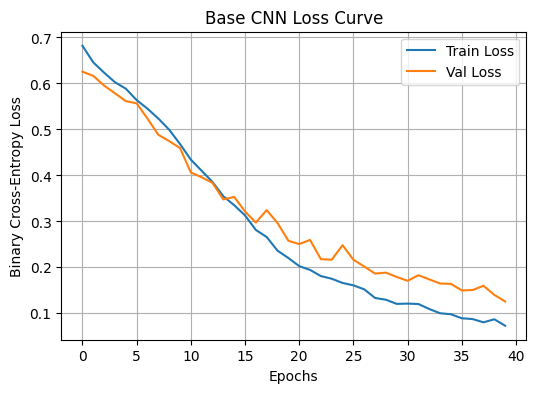

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 810ms/step

Best Threshold = 0.035
Tuned Accuracy = 81.22%
ROC-AUC        = 0.881
Cross-Entropy  = 0.8176
Confusion Matrix:
 [[339 111]
 [ 58 392]]


In [ ]:
# Build base CNN model
def train_basecnn(A_tr, B_tr, y_tr, A_te, B_te, y_te, input_shape=(IMG_H,IMG_W,1), lr=1e-3, epochs=40, batch_size=32):
    model, emb = build_siamese_baseCNN(input_shape=input_shape, embed_dim=256, lr=lr)
    metrics = train_and_eval(model, A_tr, B_tr, y_tr, A_te, B_te, y_te, model_name="Base CNN",
                             epochs=epochs, batch_size=batch_size)
    return metrics

metrics_base = train_basecnn(A_tr_g, B_tr_g, y_tr, A_te_g, B_te_g, y_te)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
102/102 - 41s - 401ms/step - accuracy: 0.5015 - loss: 0.6953 - val_accuracy: 0.5167 - val_loss: 0.6921 - learning_rate: 1.0000e-04
Epoch 2/20
102/102 - 8s - 81ms/step - accuracy: 0.5022 - loss: 0.6942 - val_accuracy: 0.5222 - val_loss: 0.6890 - learning_rate: 1.0000e-04
Epoch 3/20
102/102 - 8s - 83ms/step - accuracy: 0.4978 - loss: 0.6940 - val_accuracy: 0.5333 - val_loss: 0.6844 - learning_rate: 1.0000e-04
Epoch 4/20
102/102 - 10s - 101ms/step - accuracy: 0.5127 - loss: 0.6931 - val_accuracy: 0.5667 - val_loss: 0.6828 - learning_rate: 1.0000e-04
Epoch 5/20
102/102 - 10s - 99ms/step - accuracy: 0.5259 - loss: 0.6899 - val_accuracy: 0.5417 - val_loss: 0.6804 - learning_rate: 1.0000e-04
Epoch 6/20
102/102 - 8s - 80ms/step - accuracy: 0.5062 - loss: 0.6920 - val_accuracy: 0.5750 - val_loss: 0.6816 - learning_rate: 1.0000e-04
Epoch 7/20
102/102 - 9s - 87ms/step - accuracy: 0.5370 - loss: 0.6896 - val_accuracy: 0.5333 - val_loss:

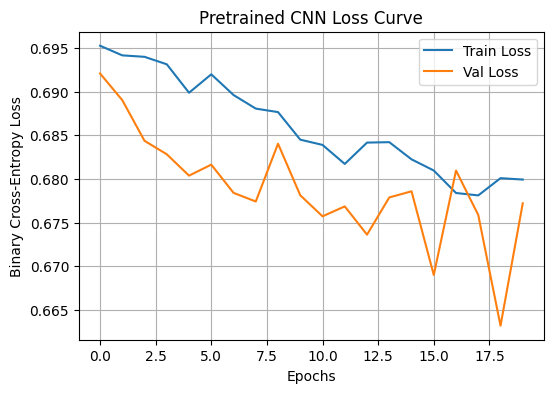

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step

Best Threshold = 0.303
Tuned Accuracy = 53.44%
ROC-AUC        = 0.578
Cross-Entropy  = 0.6860
Confusion Matrix:
 [[ 40 410]
 [  9 441]]
Epoch 1/20
102/102 - 32s - 317ms/step - accuracy: 0.5654 - loss: 0.6809 - val_accuracy: 0.6056 - val_loss: 0.6618 - learning_rate: 1.0000e-05
Epoch 2/20
102/102 - 8s - 82ms/step - accuracy: 0.5565 - loss: 0.6813 - val_accuracy: 0.6083 - val_loss: 0.6599 - learning_rate: 1.0000e-05
Epoch 3/20
102/102 - 8s - 83ms/step - accuracy: 0.5574 - loss: 0.6827 - val_accuracy: 0.5917 - val_loss: 0.6671 - learning_rate: 1.0000e-05
Epoch 4/20
102/102 - 8s - 82ms/step - accuracy: 0.5565 - loss: 0.6799 - val_accuracy: 0.5722 - val_loss: 0.6772 - learning_rate: 1.0000e-05
Epoch 5/20

Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
102/102 - 8s - 81ms/step - accuracy: 0.5651 - loss: 0.6813 - val_accuracy: 0.5556 - val_loss: 0.6729 - learning_rate: 1.0000e-05
Epoch 6/20
102/102 - 8s - 83ms/step - accuracy:

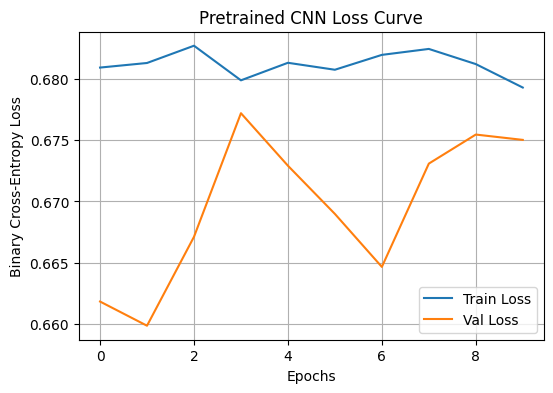

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step

Best Threshold = 0.432
Tuned Accuracy = 50.00%
ROC-AUC        = 0.491
Cross-Entropy  = 0.6960
Confusion Matrix:
 [[  0 450]
 [  0 450]]


In [ ]:
# Build pretrained CNN model
def train_pretrainedcnn(A_tr, B_tr, y_tr, A_te, B_te, y_te,
                        input_shape=(IMG_H,IMG_W,3), lr=1e-4, epochs=40, batch_size=32,
                        fine_tune_layers=15):
    model, emb = build_siamese_pretrained(input_shape=input_shape, embed_dim=256, lr=lr, freeze_backbone=True)
    _ = train_and_eval(model, A_tr, B_tr, y_tr, A_te, B_te, y_te, model_name="Pretrained CNN",
                       epochs=epochs//2, batch_size=batch_size)
    for layer in model.layers[-fine_tune_layers:]:
        layer.trainable = True
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='binary_crossentropy', metrics=['accuracy'])
    datagen = tf.keras.Sequential([
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomContrast(0.1)
    ])

    # Apply augmentation
    A_tr_aug = datagen(A_tr)
    B_tr_aug = datagen(B_tr)
    metrics = train_and_eval(model, A_tr_aug, B_tr_aug, y_tr, A_te, B_te, y_te,
                             model_name="Pretrained CNN",
                             epochs=epochs//2, batch_size=batch_size)
    return metrics

metrics_pre = train_pretrainedcnn(A_tr_rgb, B_tr_rgb, y_tr, A_te_rgb, B_te_rgb, y_te)

In [ ]:
def train_attentioncnn(A_tr, B_tr, y_tr, A_te, B_te, y_te,
                       input_shape=(IMG_H,IMG_W,1), lr=1e-4, epochs=50, batch_size=32,
                       attention_type='se'):
    model, emb = build_siamese_with_attention(input_shape=input_shape, embed_dim=256,
                                              attention=attention_type, lr=lr)
    metrics = train_and_eval(model, A_tr, B_tr, y_tr, A_te, B_te, y_te, model_name="Attention Model",
                             epochs=epochs, batch_size=batch_size)
    return metrics

metrics_se = train_attentioncnn(A_tr_g, B_tr_g, y_tr, A_te_g, B_te_g, y_te)

In [ ]:
# Build vit model
def train_vit(A_tr, B_tr, y_tr, A_te, B_te, y_te,
              image_size=(IMG_H,IMG_W,3), lr=3e-4, epochs=60, batch_size=16):
    model, emb = build_siamese_vit(image_size=image_size, lr=lr)
    metrics = train_and_eval(model, A_tr, B_tr, y_tr, A_te, B_te, y_te, model_name="ViT Model",
                             epochs=epochs, batch_size=batch_size)
    return metrics

metrics_vit = train_vit(A_tr_rgb, B_tr_rgb, y_tr, A_te_rgb, B_te_rgb, y_te)

In [ ]:
import pandas as pd

summary = pd.DataFrame([
    ['Base CNN', metrics_base['accuracy'], metrics_base['roc_auc'], metrics_base['cross_entropy']],
    ['EfficientNetB0', metrics_pre['accuracy'], metrics_pre['roc_auc'], metrics_pre['cross_entropy']],
    ['SE Attention', metrics_se['accuracy'], metrics_se['roc_auc'], metrics_se['cross_entropy']],
    ['ViT', metrics_vit['accuracy'], metrics_vit['roc_auc'], metrics_vit['cross_entropy']],
], columns=['Model', 'Accuracy (%)', 'ROC-AUC', 'Cross-Entropy'])

print("\n=== Model Comparison Summary ===")
print(summary.to_string(index=False))


In [ ]:
# Save model if needed
# siamese.save("/content/siamese_medico_colab.h5")
# print("Saved model to /content/siamese_medico_colab.h5")